In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"V:\cvs\github projects\Retail-Sales-Analysis\OnlineRetail.csv", encoding='latin1')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
top_products = df['Description'].value_counts().head(10)

print(top_products)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt

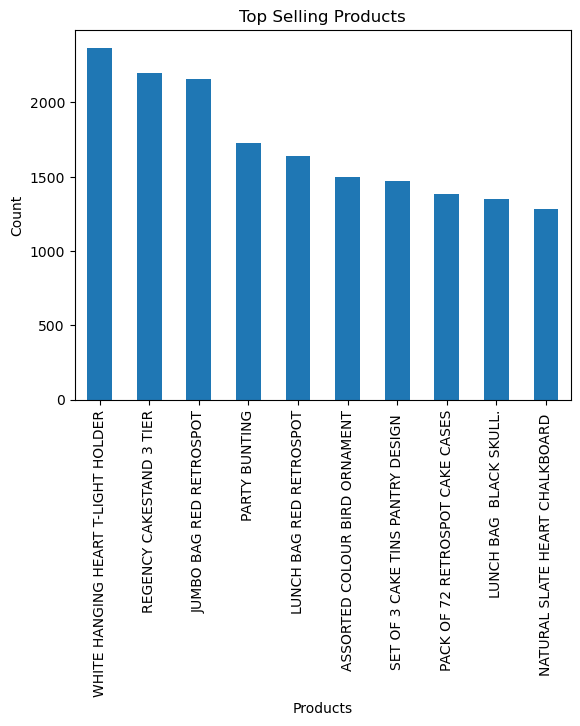

In [7]:
top_products.plot(kind='bar')

plt.title("Top Selling Products")

plt.xlabel("Products")

plt.ylabel("Count")

plt.show()

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df = df.dropna(subset=['Description', 'CustomerID'])

In [11]:
df = df.drop_duplicates()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [13]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [14]:
df['TotalPrice'].sum()

8278519.4240000015

In [16]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: TotalPrice, dtype: float64


In [17]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: TotalPrice, dtype: float64


In [18]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: TotalPrice, dtype: float64


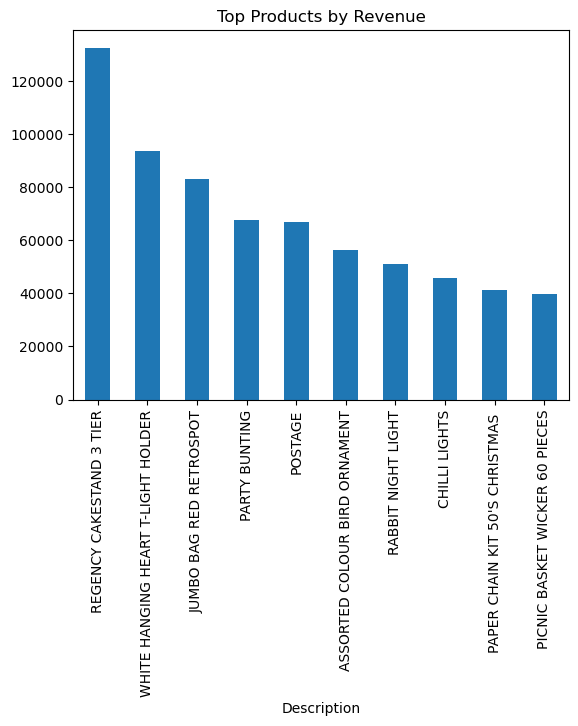

In [19]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar')
plt.title("Top Products by Revenue")
plt.show()

In [20]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [23]:
df['Month'] = df['InvoiceDate'].dt.month

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

print(monthly_sales)

Month
1      473731.900
2      435534.070
3      578576.210
4      425222.671
5      647011.670
6      606862.520
7      573112.321
8      615078.090
9      929356.232
10     973306.380
11    1126815.070
12     893912.290
Name: TotalPrice, dtype: float64


monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

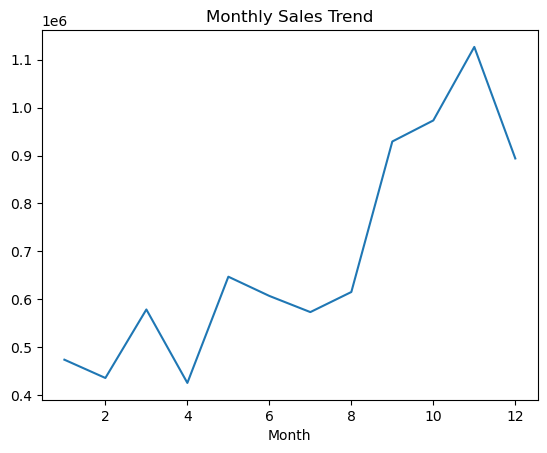

In [24]:
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

# Online Retail Sales Analysis Project

In [25]:
## 1. Data Loading
## 2. Data Cleaning
## 3. Exploratory Data Analysis
## 4. Business Insights